In [2]:
import s3fs, re, pyarrow.parquet as pq, pandas as pd, numpy as np
from scipy.ndimage import gaussian_filter1d
from s3_credentials import S3_ACCESS_KEY, S3_SECRET_KEY

OPTS={"key":S3_ACCESS_KEY,"secret":S3_SECRET_KEY,
      "client_kwargs":{"endpoint_url":"https://iseadocker.isea.rwth-aachen.de:9000","region_name":"us-east-1"},
      "config_kwargs":{"s3":{"addressing_style":"path"},"signature_version":"s3v4"}}
fs=s3fs.S3FileSystem(**OPTS)
RAWBASE="projects/j8005-metabatt/Metabatt/A123"
CAP="projects/j8005-metabatt/Metabatt/A123/40_capacity_monitore"
def TS(s): return pd.to_datetime(s,format='ISO8601')

DV_GRID=0.002; SIGMA=2; HALF_WIN=0.05; N_PTS=16; MIN_SEG=10

def extract_X_single(BID, verbose=True):
    cap=pd.read_csv(f"s3://{CAP}/METABatt_A123_APR18650M1B_{BID}_capacity.csv", storage_options=OPTS)
    cap_v=cap.dropna(subset=['Capacity_py'])
    C_min=cap_v['Capacity_py'].min()
    I_thresh=3*C_min*0.8
    if verbose: print(f"Cell {BID}: 3C阈值={I_thresh:.3f}A")

    soh=cap.dropna(subset=['SOH']).copy()
    soh['t']=TS(soh['CAP_start_time']); soh=soh.sort_values('t').reset_index(drop=True)
    soh_t=soh['t'].values.astype('datetime64[s]').astype(np.float64)
    soh_v=soh['SOH'].values

    BASE=f"{RAWBASE}/METABatt_A123_APR18650M1B_{BID}"
    aging=sorted([f for f in fs.ls(BASE) if 'Aging' in f and 'Cyc' in f],
                 key=lambda f: re.search(r'(\d{4}-\d{2}-\d{2})',f.split('/')[-1]).group(1))
    cond=re.search(r'(\d+grad_\d+SOC_\d+DOD_\d+C)',aging[0]).group(1)

    Q_list=[]; IC_list=[]; dVpeak_list=[]; hpeak_list=[]; metas=[]
    Vpeak0=None; ref_used=None
    for fi,f in enumerate(aging):
        with fs.open(f) as fh:
            d=pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom','Prozedur']).to_pandas()
        d=d[d['Prozedur'].str.contains('Aging_APR_Cyc')].reset_index(drop=True)
        if len(d)==0: continue
        d['Zeit']=TS(d['Zeit'])
        is_dch=(d['Strom'].values<-I_thresh)
        diff=np.diff(is_dch.astype(int))
        starts=np.where(diff==1)[0]+1; ends=np.where(diff==-1)[0]+1
        if is_dch[0]: starts=np.r_[0,starts]
        if is_dch[-1]: ends=np.r_[ends,len(d)]
        segs=[(s,e) for s,e in zip(starts,ends) if e-s>=MIN_SEG]

        for (s,e) in segs:
            seg=d.iloc[s:e]
            t=(seg['Zeit']-seg['Zeit'].iloc[0]).dt.total_seconds().values
            V=seg['Spannung'].values; I=seg['Strom'].values
            Q=np.cumsum(np.abs(I)*np.diff(t,prepend=t[0])/3600.0)
            o=np.argsort(V); Vu,idx=np.unique(V[o],return_index=True); Qu=Q[o][idx]
            if len(Vu)<5: continue
            vgrid=np.arange(Vu.min(),Vu.max(),DV_GRID)
            if len(vgrid)<N_PTS: continue
            Qsm=gaussian_filter1d(np.interp(vgrid,Vu,Qu),sigma=SIGMA)
            IC=np.abs(np.gradient(Qsm,vgrid))
            ip=IC.argmax(); Vpeak=vgrid[ip]

            v_lo,v_hi=Vpeak-HALF_WIN,Vpeak+HALF_WIN
            if v_lo<vgrid.min() or v_hi>vgrid.max(): continue   # 不外推,跳过
            v_sample=np.linspace(v_lo,v_hi,N_PTS)

            # 第一个通过所有检查的样本作为参考(记录下来)
            if Vpeak0 is None:
                Vpeak0=Vpeak; ref_used=(fi, seg['Zeit'].iloc[0])

            Q_s   =np.interp(v_sample,vgrid,Qsm)   # 原始Q(峰窗16点)
            IC_s  =np.interp(v_sample,vgrid,IC)    # 原始IC(峰窗16点)
            h_peak=IC.max()                        # 峰高(标量1)
            dVpeak=Vpeak0-Vpeak                    # 峰移(标量2)

            t_sec=np.float64(seg['Zeit'].iloc[0].value)//10**9
            soh_label=np.interp(t_sec,soh_t,soh_v)

            Q_list.append(Q_s); IC_list.append(IC_s)
            hpeak_list.append(h_peak); dVpeak_list.append(dVpeak)
            metas.append({'file':fi,'t_start':seg['Zeit'].iloc[0],'Vpeak':Vpeak,
                          'SOH':soh_label,'V_min':V.min(),'V_max':V.max(),'I_mean':I.mean(),'cond':cond})

    if len(Q_list)==0: print("⚠️ 无样本"); return None,None

    Q_arr=np.array(Q_list); IC_arr=np.array(IC_list)
    hpeak_arr=np.array(hpeak_list); dVpeak_arr=np.array(dVpeak_list)
    dQ_arr=Q_arr-Q_arr[0]    # ΔQ:相对第一个参考样本,按序号相减

    # 50维:Q(16) + ΔQ(16) + IC(16) + h_peak(1) + ΔVpeak(1)
    cols=[f'Q_{i}' for i in range(N_PTS)]+[f'dQ_{i}' for i in range(N_PTS)]+\
         [f'IC_{i}' for i in range(N_PTS)]+['h_peak','dVpeak']
    X=np.column_stack([Q_arr, dQ_arr, IC_arr, hpeak_arr, dVpeak_arr])
    X_df=pd.DataFrame(X,columns=cols)
    meta_df=pd.DataFrame(metas)
    X_df['SOH']=meta_df['SOH'].values

    if verbose:
        print(f"提取 {len(X_df)} 样本, {len(cols)}维特征(原始量,未归一化)+SOH")
        print(f"参考循环(Vpeak0): file{ref_used[0]}, {ref_used[1]}, Vpeak0={Vpeak0:.4f}V")
        print(f"SOH范围 {meta_df['SOH'].min():.1f}~{meta_df['SOH'].max():.1f}")
        print(f"Q范围 {Q_arr.min():.4f}~{Q_arr.max():.4f}")
        print(f"IC范围 {IC_arr.min():.3f}~{IC_arr.max():.3f}")
        print(f"h_peak范围 {hpeak_arr.min():.3f}~{hpeak_arr.max():.3f}")
        print(f"ΔVpeak范围 {dVpeak_arr.min():.4f}~{dVpeak_arr.max():.4f}")
    return X_df, meta_df

X_df, meta_df = extract_X_single("008")
X_df.to_csv("X_008_raw.csv", index=False)
print(f"saved X_008_raw.csv, shape={X_df.shape}")   # 应该是 (样本数, 51) = 50特征+SOH
X_df.head()

Cell 008: 3C阈值=2.084A
提取 7703 样本, 50维特征(原始量,未归一化)+SOH
参考循环(Vpeak0): file0, 2024-12-20 23:34:43.340000+00:00, Vpeak0=3.2161V
SOH范围 72.5~96.5
Q范围 0.0013~0.6494
IC范围 0.134~9.939
h_peak范围 6.585~10.099
ΔVpeak范围 -0.0224~0.0087
saved X_008_raw.csv, shape=(7703, 51)


,Q_0,Q_1,Q_2,Q_3,Q_4,Q_5,Q_6,Q_7,Q_8,Q_9,...,IC_9,IC_10,IC_11,IC_12,IC_13,IC_14,IC_15,h_peak,dVpeak,SOH
0,0.621625,0.575413,0.527621,0.478740,0.428444,0.376116,0.319860,0.257788,0.192937,0.132990,...,8.366456,7.164279,4.974240,1.973248,0.714600,0.384780,0.259960,9.781188,0.000000,96.5
1,0.624120,0.579065,0.532785,0.485336,0.436344,0.384842,0.328809,0.266150,0.200034,0.138218,...,8.663132,7.397949,5.187329,2.033454,0.720904,0.391701,0.267658,9.969800,0.000222,96.5
2,0.637188,0.593177,0.547500,0.500412,0.451633,0.400531,0.345382,0.283392,0.216936,0.152988,...,9.061642,7.807159,5.910498,2.616076,0.868199,0.432110,0.288979,10.012259,0.001667,96.5
3,0.625083,0.580516,0.534573,0.487396,0.438273,0.386379,0.329557,0.265852,0.199100,0.136843,...,8.705234,7.443808,5.061832,1.897147,0.676223,0.378488,0.264726,10.061126,-0.000222,96.5
4,0.625795,0.581800,0.536162,0.489163,0.440200,0.388505,0.331864,0.268567,0.201831,0.139393,...,8.735296,7.518911,5.218830,1.977230,0.693422,0.386435,0.268177,10.060917,0.000111,96.5


In [2]:
# ===== 按工况各取代表电池测试(不同DOD都试)=====
# 依赖 extract_X_single() 50维版已定义

import pandas as pd, os, time

meta=pd.read_csv('usable_batteries.csv')
meta['bid']=meta['bid'].apply(lambda x:f'{int(x):03d}')

# 排除20DOD,每个DOD取2块代表(尽量覆盖不同SOC/温度)
todo=[]
for dod in [40,60,80,100]:
    sub=meta[meta['DOD']==dod]
    # 每个DOD取2块,尽量不同工况
    picks=sub.drop_duplicates(subset=['Temp','SOC']).head(2)
    if len(picks)<2:  # 不够就补
        picks=sub.head(2)
    for _,r in picks.iterrows():
        todo.append((r['bid'], f"{r['Temp']}C_{r['SOC']}SOC_{r['DOD']}DOD"))

print(f"测试 {len(todo)} 块(覆盖DOD 40/60/80/100):")
for b,c in todo: print(f"  {b}: {c}")
print()

os.makedirs('X_features', exist_ok=True)
results=[]
for i,(bid,label) in enumerate(todo):
    t0=time.time()
    try:
        X_df, meta_df = extract_X_single(bid, verbose=False)
        if X_df is None:
            print(f"[{i+1}/{len(todo)}] {bid} ({label}) ⚠️无样本"); continue
        X_df.to_csv(f'X_features/X_{bid}.csv', index=False)
        results.append({'bid':bid,'label':label,'n':len(X_df),'dim':X_df.shape[1]-1,
                        'SOH_min':meta_df['SOH'].min(),'SOH_max':meta_df['SOH'].max(),
                        'V_min':meta_df['V_min'].min(),'V_max':meta_df['V_max'].max(),
                        'IC_max':X_df[[c for c in X_df.columns if c.startswith('IC_')]].max().max()})
        print(f"[{i+1}/{len(todo)}] {bid} ({label}): {len(X_df)}样本 {X_df.shape[1]-1}维, "
              f"SOH {meta_df['SOH'].min():.1f}~{meta_df['SOH'].max():.1f}, "
              f"V {meta_df['V_min'].min():.2f}~{meta_df['V_max'].max():.2f}, {time.time()-t0:.0f}s")
    except Exception as ex:
        print(f"[{i+1}/{len(todo)}] {bid} ({label}) ❌ {str(ex)[:60]}")

print(f"\n{'='*55}")
summary=pd.DataFrame(results)
print(summary.to_string(index=False))

测试 8 块(覆盖DOD 40/60/80/100):
  072: 25C_50SOC_40DOD
  074: 25C_70SOC_40DOD
  007: 35C_70SOC_60DOD
  011: 35C_30SOC_60DOD
  153: 35C_50SOC_80DOD
  162: 15C_50SOC_80DOD
  028: 35C_50SOC_100DOD
  163: 15C_50SOC_100DOD

[1/8] 072 (25C_50SOC_40DOD) ❌ name 'extract_X_single' is not defined
[2/8] 074 (25C_70SOC_40DOD) ❌ name 'extract_X_single' is not defined
[3/8] 007 (35C_70SOC_60DOD) ❌ name 'extract_X_single' is not defined
[4/8] 011 (35C_30SOC_60DOD) ❌ name 'extract_X_single' is not defined
[5/8] 153 (35C_50SOC_80DOD) ❌ name 'extract_X_single' is not defined
[6/8] 162 (15C_50SOC_80DOD) ❌ name 'extract_X_single' is not defined
[7/8] 028 (35C_50SOC_100DOD) ❌ name 'extract_X_single' is not defined
[8/8] 163 (15C_50SOC_100DOD) ❌ name 'extract_X_single' is not defined

Empty DataFrame
Columns: []
Index: []


In [3]:
import s3fs, re, pyarrow.parquet as pq, pandas as pd, numpy as np
from s3_credentials import S3_ACCESS_KEY, S3_SECRET_KEY

OPTS={"key":S3_ACCESS_KEY,"secret":S3_SECRET_KEY,
      "client_kwargs":{"endpoint_url":"https://iseadocker.isea.rwth-aachen.de:9000","region_name":"us-east-1"},
      "config_kwargs":{"s3":{"addressing_style":"path"},"signature_version":"s3v4"}}
fs=s3fs.S3FileSystem(**OPTS)
RAWBASE="projects/j8005-metabatt/Metabatt/A123"
CAP="projects/j8005-metabatt/Metabatt/A123/40_capacity_monitore"
def TS(s): return pd.to_datetime(s,format='ISO8601')

def check_vmin_distribution(BID):
    """统计该电池所有3C放电段的谷底电压分布"""
    cap=pd.read_csv(f"s3://{CAP}/METABatt_A123_APR18650M1B_{BID}_capacity.csv",storage_options=OPTS)
    I_thresh=3*cap.dropna(subset=['Capacity_py'])['Capacity_py'].min()*0.8
    BASE=f"{RAWBASE}/METABatt_A123_APR18650M1B_{BID}"
    aging=sorted([f for f in fs.ls(BASE) if 'Aging' in f and 'Cyc' in f],
                 key=lambda f: re.search(r'(\d{4}-\d{2}-\d{2})',f.split('/')[-1]).group(1))
    cond=re.search(r'(\d+grad_\d+SOC_\d+DOD_\d+C)',aging[0]).group(1)
    vmins=[]
    for f in aging:
        with fs.open(f) as fh:
            d=pq.ParquetFile(fh).read(columns=['Spannung','Strom','Prozedur']).to_pandas()
        d=d[d['Prozedur'].str.contains('Aging_APR_Cyc')].reset_index(drop=True)
        if len(d)==0: continue
        is_dch=(d['Strom'].values<-I_thresh)
        diff=np.diff(is_dch.astype(int))
        starts=np.where(diff==1)[0]+1; ends=np.where(diff==-1)[0]+1
        if is_dch[0]: starts=np.r_[0,starts]
        if is_dch[-1]: ends=np.r_[ends,len(d)]
        for s,e in zip(starts,ends):
            if e-s>=10: vmins.append(d['Spannung'].iloc[s:e].min())
    vmins=np.array(vmins)
    # 分布统计
    print(f"\n{BID} ({cond}): {len(vmins)}个放电段")
    print(f"  谷底V: 最低{vmins.min():.3f}, 中位{np.median(vmins):.3f}, 最高{vmins.max():.3f}")
    print(f"  分布: <2.2V:{(vmins<2.2).sum()}段  2.2-2.5:{((vmins>=2.2)&(vmins<2.5)).sum()}  "
          f"2.5-2.8:{((vmins>=2.5)&(vmins<2.8)).sum()}  >2.8:{(vmins>=2.8).sum()}")

for bid in ['072','074','007','011','153','162','028','163']:
    check_vmin_distribution(bid)


072 (25grad_50SOC_40DOD_3C): 11181个放电段
  谷底V: 最低1.995, 中位2.697, 最高3.120
  分布: <2.2V:323段  2.2-2.5:1508  2.5-2.8:6888  >2.8:2462

074 (25grad_70SOC_40DOD_3C): 11180个放电段
  谷底V: 最低1.995, 中位2.702, 最高3.151
  分布: <2.2V:338段  2.2-2.5:1542  2.5-2.8:6731  >2.8:2569

007 (35grad_70SOC_60DOD_3C): 8141个放电段
  谷底V: 最低3.113, 中位3.132, 最高3.210
  分布: <2.2V:0段  2.2-2.5:0  2.5-2.8:0  >2.8:8141

011 (35grad_30SOC_60DOD_3C): 7712个放电段
  谷底V: 最低1.965, 中位1.993, 最高3.181
  分布: <2.2V:7698段  2.2-2.5:10  2.5-2.8:3  >2.8:1

153 (35grad_50SOC_80DOD_3C): 7604个放电段
  谷底V: 最低1.968, 中位1.994, 最高2.543
  分布: <2.2V:7560段  2.2-2.5:43  2.5-2.8:1  >2.8:0

162 (15grad_50SOC_80DOD_3C): 6115个放电段
  谷底V: 最低1.994, 中位1.998, 最高3.133
  分布: <2.2V:5683段  2.2-2.5:319  2.5-2.8:112  >2.8:1

028 (35grad_50SOC_100DOD_3C): 4430个放电段
  谷底V: 最低1.973, 中位1.993, 最高3.047
  分布: <2.2V:4419段  2.2-2.5:7  2.5-2.8:3  >2.8:1

163 (15grad_50SOC_100DOD_3C): 4309个放电段
  谷底V: 最低1.992, 中位1.998, 最高2.197
  分布: <2.2V:4309段  2.2-2.5:0  2.5-2.8:0  >2.8:0


In [4]:
import s3fs, re, pyarrow.parquet as pq, pandas as pd, numpy as np
from s3_credentials import S3_ACCESS_KEY, S3_SECRET_KEY

OPTS={"key":S3_ACCESS_KEY,"secret":S3_SECRET_KEY,
      "client_kwargs":{"endpoint_url":"https://iseadocker.isea.rwth-aachen.de:9000","region_name":"us-east-1"},
      "config_kwargs":{"s3":{"addressing_style":"path"},"signature_version":"s3v4"}}
fs=s3fs.S3FileSystem(**OPTS)
RAWBASE="projects/j8005-metabatt/Metabatt/A123"
CAP="projects/j8005-metabatt/Metabatt/A123/40_capacity_monitore"
def TS(s): return pd.to_datetime(s,format='ISO8601')

def find_low_segments(BID, V_TH=2.2):
    """找出谷底<V_TH的放电段,列出时间位置"""
    cap=pd.read_csv(f"s3://{CAP}/METABatt_A123_APR18650M1B_{BID}_capacity.csv",storage_options=OPTS)
    I_thresh=3*cap.dropna(subset=['Capacity_py'])['Capacity_py'].min()*0.8
    BASE=f"{RAWBASE}/METABatt_A123_APR18650M1B_{BID}"
    aging=sorted([f for f in fs.ls(BASE) if 'Aging' in f and 'Cyc' in f],
                 key=lambda f: re.search(r'(\d{4}-\d{2}-\d{2})',f.split('/')[-1]).group(1))
    cond=re.search(r'(\d+grad_\d+SOC_\d+DOD_\d+C)',aging[0]).group(1)
    def fdate(f): return re.search(r'(\d{4}-\d{2}-\d{2})',f.split('/')[-1]).group(1)

    lows=[]; total=0
    for fi,f in enumerate(aging):
        with fs.open(f) as fh:
            d=pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom','Prozedur']).to_pandas()
        d=d[d['Prozedur'].str.contains('Aging_APR_Cyc')].reset_index(drop=True)
        if len(d)==0: continue
        d['Zeit']=TS(d['Zeit'])
        is_dch=(d['Strom'].values<-I_thresh)
        diff=np.diff(is_dch.astype(int))
        starts=np.where(diff==1)[0]+1; ends=np.where(diff==-1)[0]+1
        if is_dch[0]: starts=np.r_[0,starts]
        if is_dch[-1]: ends=np.r_[ends,len(d)]
        for s,e in zip(starts,ends):
            if e-s<10: continue
            total+=1
            seg=d.iloc[s:e]; vmin=seg['Spannung'].min()
            if vmin<V_TH:
                imin=seg['Spannung'].idxmin()
                lows.append({'file':fi,'date':fdate(f),'t_min':d.loc[imin,'Zeit'],
                             'vmin':vmin,'dur_s':(seg['Zeit'].iloc[-1]-seg['Zeit'].iloc[0]).total_seconds(),
                             'I_mean':seg['Strom'].mean()})
    low_df=pd.DataFrame(lows)
    print(f"\n{'='*60}\n{BID} ({cond}): {total}段中 {len(low_df)}段谷底<{V_TH}V")
    if len(low_df)>0:
        # 按文件统计:低压段集中在哪些文件
        by_file=low_df.groupby(['file','date']).agg(n=('vmin','count'),
                 vmin=('vmin','min'),dur=('dur_s','mean')).reset_index()
        print("低压段按文件分布:")
        print(by_file.to_string(index=False))
        print(f"\n最低的5段:")
        print(low_df.nsmallest(5,'vmin')[['date','t_min','vmin','dur_s','I_mean']].to_string(index=False))
    return low_df

for bid in ['072','074','007']:
    find_low_segments(bid)


072 (25grad_50SOC_40DOD_3C): 11181段中 323段谷底<2.2V
低压段按文件分布:
 file       date  n     vmin        dur
    2 2024-12-23 10 2.077941 480.093000
    3 2025-01-10 22 1.996037 479.996364
    4 2025-01-30 17 1.997371 479.928235
    5 2025-02-16 16 1.995593 479.965625
    6 2025-03-07 12 1.996259 479.970833
    7 2025-03-24 14 1.995370 479.992857
    8 2025-04-26 11 1.996482 479.943636
    9 2025-05-14 12 1.996593 479.963333
   10 2025-06-05 14 1.996815 479.863571
   11 2025-06-22 14 1.995481 479.897143
   12 2025-07-11 10 1.996815 479.953000
   13 2025-07-28 12 1.996148 479.982500
   14 2025-08-16 13 1.995259 479.845385
   15 2025-09-02 13 1.996704 479.890000
   16 2025-09-20 11 1.995704 479.866364
   17 2025-10-07 10 1.995370 479.980000
   18 2025-10-24 13 1.996815 479.902308
   19 2025-11-10 16 1.996148 479.890000
   20 2025-11-28 14 1.996148 479.489286
   21 2025-12-15 15 1.995481 479.940667
   22 2026-01-01 12 1.995815 479.930833
   23 2026-01-18 15 1.995481 479.950000
   24 2026-02-07 14 

In [5]:
# ===== 全量提取 X:全部都跑,20DOD单独存放 =====
# 前置:extract_X_single() 50维版必须已定义并运行过

import pandas as pd, os, time

meta=pd.read_csv('usable_batteries.csv')
meta['bid']=meta['bid'].apply(lambda x:f'{int(x):03d}')

# 两个输出目录
OUT_MAIN='X_features'        # 非20DOD
OUT_20  ='X_features_20DOD'  # 20DOD单独放
os.makedirs(OUT_MAIN, exist_ok=True)
os.makedirs(OUT_20,   exist_ok=True)

todo=meta[['bid','DOD']].values.tolist()
print(f"目标:{len(todo)}块电池全部跑")
print(f"  非20DOD → {OUT_MAIN}/")
print(f"  20DOD   → {OUT_20}/\n")

results=[]; failed=[]
t_all=time.time()
for i,(bid,dod) in enumerate(todo):
    out_dir = OUT_20 if dod==20 else OUT_MAIN
    out_path=f'{out_dir}/X_{bid}.csv'
    # 断点续跑:已存在就跳过
    if os.path.exists(out_path):
        print(f"[{i+1}/{len(todo)}] {bid} (DOD{dod}) 已存在,跳过")
        continue
    t0=time.time()
    try:
        X_df, meta_df = extract_X_single(bid, verbose=False)
        if X_df is None:
            failed.append((bid,'无样本'))
            print(f"[{i+1}/{len(todo)}] {bid} (DOD{dod}) ⚠️无样本"); continue
        X_df.to_csv(out_path, index=False)
        cond=meta_df['cond'].iloc[0]
        results.append({'bid':bid,'DOD':dod,'cond':cond,'n':len(X_df),'dim':X_df.shape[1]-1,
                        'SOH_min':meta_df['SOH'].min(),'SOH_max':meta_df['SOH'].max(),
                        'V_min':meta_df['V_min'].min(),'V_max':meta_df['V_max'].max()})
        print(f"[{i+1}/{len(todo)}] {bid} ({cond}): {len(X_df)}样本 {X_df.shape[1]-1}维, "
              f"SOH {meta_df['SOH'].min():.1f}~{meta_df['SOH'].max():.1f}, "
              f"V {meta_df['V_min'].min():.2f}~{meta_df['V_max'].max():.2f}, {time.time()-t0:.0f}s")
    except Exception as ex:
        failed.append((bid,str(ex)[:60]))
        print(f"[{i+1}/{len(todo)}] {bid} (DOD{dod}) ❌ {str(ex)[:60]}")

# ===== 汇总 =====
summary=pd.DataFrame(results)
summary.to_csv(f'{OUT_MAIN}/_summary_all.csv', index=False)
print(f"\n{'='*60}")
print(f"完成! 成功{len(results)}块, 失败{len(failed)}块, 总耗时{(time.time()-t_all)/60:.1f}分钟")
if len(summary)>0:
    print(f"总样本数: {summary['n'].sum()}")
    print(f"\n按DOD统计:")
    print(summary.groupby('DOD').agg(电池数=('bid','count'),样本数=('n','sum'),
          维度=('dim','first')).to_string())
if failed:
    print(f"\n失败的{len(failed)}块:")
    for b,e in failed: print(f"  {b}: {e}")

目标:286块电池全部跑
  非20DOD → X_features/
  20DOD   → X_features_20DOD/

[1/286] 007 (DOD60) 已存在,跳过
[2/286] 008 (DOD60) 已存在,跳过
[3/286] 009 (DOD60) 已存在,跳过
[4/286] 010 (DOD60) 已存在,跳过
[5/286] 011 (DOD60) 已存在,跳过
[6/286] 012 (DOD20) 已存在,跳过
[7/286] 013 (DOD20) 已存在,跳过
[8/286] 014 (DOD20) 已存在,跳过
[9/286] 015 (DOD20) 已存在,跳过
[10/286] 016 (DOD60) 已存在,跳过
[11/286] 017 (DOD60) 已存在,跳过
[12/286] 018 (DOD60) 已存在,跳过
[13/286] 019 (DOD60) 已存在,跳过
[14/286] 020 (DOD60) 已存在,跳过
[15/286] 021 (DOD60) 已存在,跳过
[16/286] 022 (DOD60) 已存在,跳过
[17/286] 023 (DOD60) 已存在,跳过
[18/286] 024 (DOD60) 已存在,跳过
[19/286] 025 (DOD60) 已存在,跳过
[20/286] 027 (DOD60) 已存在,跳过
[21/286] 028 (DOD100) 已存在,跳过
[22/286] 032 (DOD60) 已存在,跳过
[23/286] 033 (DOD100) 已存在,跳过
[24/286] 037 (DOD60) 已存在,跳过
[25/286] 038 (DOD20) 已存在,跳过
[26/286] 045 (DOD20) 已存在,跳过
[27/286] 050 (DOD20) 已存在,跳过
[28/286] 052 (DOD100) 已存在,跳过
[29/286] 055 (DOD100) 已存在,跳过
[30/286] 056 (DOD60) 已存在,跳过
[31/286] 059 (DOD60) 已存在,跳过
[32/286] 060 (DOD60) 已存在,跳过
[33/286] 061 (DOD100) 已存在,跳过
[34/286] 062 

In [6]:
import pandas as pd, numpy as np, os, glob

# 读所有提取的csv(两个文件夹)
files = glob.glob('X_features/X_*.csv') + glob.glob('X_features_20DOD/X_*.csv')
meta = pd.read_csv('usable_batteries.csv'); meta['bid']=meta['bid'].apply(lambda x:f'{int(x):03d}')
cond_map = meta.set_index('bid')[['Temp','SOC','DOD']].to_dict('index')

print(f"找到 {len(files)} 个特征文件\n")

Q_cols=[f'Q_{i}' for i in range(16)]
dQ_cols=[f'dQ_{i}' for i in range(16)]
IC_cols=[f'IC_{i}' for i in range(16)]

rows=[]
for f in sorted(files):
    bid=os.path.basename(f).replace('X_','').replace('.csv','')
    df=pd.read_csv(f)
    info=cond_map.get(bid,{})
    rows.append({
        'bid':bid, 'DOD':info.get('DOD'), 'SOC':info.get('SOC'), 'Temp':info.get('Temp'),
        'n':len(df), 'dim':df.shape[1]-1,
        'has_nan':df.isna().any().any(), 'has_inf':np.isinf(df.select_dtypes('number')).any().any(),
        'SOH_min':df['SOH'].min(), 'SOH_max':df['SOH'].max(),
        'SOH_monotone': (df['SOH'].diff().dropna()<=0.5).mean(),  # 大致单调下降比例
        'Q_max':df[Q_cols].max().max(), 'IC_max':df[IC_cols].max().max(),
        'dQ_absmax':df[dQ_cols].abs().max().max(),
        'hpeak_max':df['h_peak'].max(), 'dVpeak_absmax':df['dVpeak'].abs().max(),
    })
chk=pd.DataFrame(rows)

# ===== 1. 完整性 =====
print("="*60); print("【1. 完整性】")
print(f"总文件: {len(chk)}  (期望286)")
print(f"维度!=50的: {(chk['dim']!=50).sum()} 块")
print(f"含NaN的: {chk['has_nan'].sum()} 块; 含Inf的: {chk['has_inf'].sum()} 块")
print(f"样本数: 最少{chk['n'].min()}({chk.loc[chk['n'].idxmin(),'bid']}), "
      f"最多{chk['n'].max()}, 中位{chk['n'].median():.0f}")

# ===== 2. 数值合理性:标记异常 =====
print("\n"+"="*60); print("【2. 异常标记】")
flags=[]
# SOH应在合理范围(比如40-105)
bad_soh=chk[(chk['SOH_min']<40)|(chk['SOH_max']>105)|(chk['SOH_max']<90)]
if len(bad_soh): print(f"⚠️ SOH范围可疑({len(bad_soh)}块):"); print(bad_soh[['bid','DOD','SOH_min','SOH_max']].to_string(index=False))
# 样本太少
bad_n=chk[chk['n']<500]
if len(bad_n): print(f"⚠️ 样本过少<500({len(bad_n)}块):"); print(bad_n[['bid','DOD','n']].to_string(index=False))
# 特征爆表(IC或Q异常大)
bad_feat=chk[(chk['IC_max']>50)|(chk['Q_max']>5)|(chk['hpeak_max']>50)]
if len(bad_feat): print(f"⚠️ 特征值异常大({len(bad_feat)}块):"); print(bad_feat[['bid','Q_max','IC_max','hpeak_max']].to_string(index=False))
# 有NaN/Inf
bad_nan=chk[chk['has_nan']|chk['has_inf']]
if len(bad_nan): print(f"❌ 含NaN/Inf({len(bad_nan)}块):"); print(bad_nan[['bid']].to_string(index=False))

# ===== 3. 按工况一致性 =====
print("\n"+"="*60); print("【3. 按DOD分组统计】")
g=chk.groupby('DOD').agg(电池数=('bid','count'),样本中位=('n','median'),
    SOH最低均值=('SOH_min','mean'),IC最大均值=('IC_max','mean')).round(1)
print(g.to_string())

# ===== 4. 保存体检报告 =====
chk.to_csv('X_features/_health_check.csv',index=False)
print("\n已存 _health_check.csv (每块详细指标)")

找到 272 个特征文件

【1. 完整性】
总文件: 272  (期望286)
维度!=50的: 0 块
含NaN的: 0 块; 含Inf的: 0 块
样本数: 最少2898(471), 最多13740, 中位8127

【2. 异常标记】

【3. 按DOD分组统计】
     电池数     样本中位  SOH最低均值  IC最大均值
DOD                               
20   108  11358.0     87.7     1.9
40    47  10317.0     83.5     4.0
60    82   8071.0     81.3     7.4
80    10   5793.0     72.4     8.2
100   25   4275.0     72.0     9.3

已存 _health_check.csv (每块详细指标)


In [7]:
# 验证:90SOC 20DOD 的放电电压范围
import s3fs, re, pyarrow.parquet as pq, pandas as pd, numpy as np
from s3_credentials import S3_ACCESS_KEY, S3_SECRET_KEY
OPTS={"key":S3_ACCESS_KEY,"secret":S3_SECRET_KEY,
      "client_kwargs":{"endpoint_url":"https://iseadocker.isea.rwth-aachen.de:9000","region_name":"us-east-1"},
      "config_kwargs":{"s3":{"addressing_style":"path"},"signature_version":"s3v4"}}
fs=s3fs.S3FileSystem(**OPTS)
CAP="projects/j8005-metabatt/Metabatt/A123/40_capacity_monitore"
BID="084"
cap=pd.read_csv(f"s3://{CAP}/METABatt_A123_APR18650M1B_{BID}_capacity.csv",storage_options=OPTS)
I_thresh=3*cap.dropna(subset=['Capacity_py'])['Capacity_py'].min()*0.8
BASE=f"projects/j8005-metabatt/Metabatt/A123/METABatt_A123_APR18650M1B_{BID}"
aging=sorted([f for f in fs.ls(BASE) if 'Aging' in f and 'Cyc' in f])
with fs.open(aging[len(aging)//2]) as fh:
    d=pq.ParquetFile(fh).read(columns=['Spannung','Strom','Prozedur']).to_pandas()
d=d[d['Prozedur'].str.contains('Aging_APR_Cyc')]
dch=d[d['Strom']<-I_thresh]
print(f"{BID} (90SOC 20DOD) 放电电压范围: {dch['Spannung'].min():.3f} ~ {dch['Spannung'].max():.3f}V")
print(f"IC峰通常在3.10-3.20V — 如果放电最低电压>3.20V,就扫不到峰,提取必然失败")

084 (90SOC 20DOD) 放电电压范围: 3.171 ~ 3.301V
IC峰通常在3.10-3.20V — 如果放电最低电压>3.20V,就扫不到峰,提取必然失败


In [8]:
import pandas as pd, numpy as np, glob, os

# 挑几块代表(不同DOD)
sample_bids=['072','007','153','028']  # 40/60/80/100 DOD,按你有的改
FEAT=[f'Q_{i}' for i in range(16)]+[f'dQ_{i}' for i in range(16)]+\
     [f'IC_{i}' for i in range(16)]+['h_peak','dVpeak']

# 合并这几块
dfs=[]
for bid in sample_bids:
    p=f'X_train/X_{bid}.csv'
    if not os.path.exists(p): p=f'X_test/X_{bid}.csv'
    if os.path.exists(p):
        d=pd.read_csv(p); d['bid']=bid; dfs.append(d)
df=pd.concat(dfs,ignore_index=True)
print(f"合并 {len(df)} 样本, 来自 {df['bid'].nunique()} 块\n")

# ===== 1. 每类特征的整体统计 =====
print("="*60); print("【1. 各特征组的范围】")
for grp,cols in [('Q',[f'Q_{i}' for i in range(16)]),
                 ('dQ',[f'dQ_{i}' for i in range(16)]),
                 ('IC',[f'IC_{i}' for i in range(16)]),
                 ('h_peak',['h_peak']),('dVpeak',['dVpeak'])]:
    vals=df[cols].values.flatten()
    print(f"  {grp:8s}: min{vals.min():.4f} max{vals.max():.4f} "
          f"mean{vals.mean():.4f} std{vals.std():.4f}")

# ===== 2. 死特征检测(方差接近0)=====
print("\n"+"="*60); print("【2. 低方差特征(可能是死特征)】")
stds=df[FEAT].std()
dead=stds[stds<0.001]
print(f"  std<0.001的列: {list(dead.index) if len(dead) else '无'}")

# ===== 3. 每个特征与SOH的相关性 =====
print("\n"+"="*60); print("【3. 特征与SOH的相关性(绝对值前10)】")
corr=df[FEAT].corrwith(df['SOH']).abs().sort_values(ascending=False)
print(corr.head(10).to_string())
print(f"\n  相关性最弱的5个:")
print(corr.tail(5).to_string())

# ===== 4. h_peak vs IC_8 冗余检查 =====
print("\n"+"="*60); print("【4. 冗余检查】")
print(f"  h_peak vs IC_8 相关性: {df['h_peak'].corr(df['IC_8']):.4f}")
print(f"  IC_7 vs IC_8 相关性:   {df['IC_7'].corr(df['IC_8']):.4f}")
print(f"  Q_0 vs Q_1 相关性:     {df['Q_0'].corr(df['Q_1']):.4f}")

# ===== 5. dVpeak 分布(之前担心偏大)=====
print("\n"+"="*60); print("【5. dVpeak分布】")
print(f"  范围 {df['dVpeak'].min():.4f}~{df['dVpeak'].max():.4f}")
print(f"  |dVpeak|>0.1的样本占比: {(df['dVpeak'].abs()>0.1).mean()*100:.1f}%")

合并 31333 样本, 来自 4 块

【1. 各特征组的范围】
  Q       : min0.0007 max0.6531 mean0.1679 std0.1505
  dQ      : min-0.5716 max0.1508 mean-0.0187 std0.0767
  IC      : min0.1335 max10.1188 mean3.7128 std2.3321
  h_peak  : min0.5052 max10.3564 mean5.7277 std2.1847
  dVpeak  : min-0.0169 max0.1439 mean0.0107 std0.0155

【2. 低方差特征(可能是死特征)】
  std<0.001的列: 无

【3. 特征与SOH的相关性(绝对值前10)】
dQ_0    0.757259
dQ_1    0.751372
dQ_2    0.744623
dQ_3    0.736105
dQ_4    0.724925
dQ_5    0.709575
dQ_6    0.687550
dQ_7    0.655146
dQ_8    0.609650
dQ_9    0.554911

  相关性最弱的5个:
Q_15     0.060013
Q_13     0.054794
IC_15    0.038871
Q_14     0.020511
dQ_15    0.017066

【4. 冗余检查】
  h_peak vs IC_8 相关性: 0.9990
  IC_7 vs IC_8 相关性:   0.9991
  Q_0 vs Q_1 相关性:     0.9994

【5. dVpeak分布】
  范围 -0.0169~0.1439
  |dVpeak|>0.1的样本占比: 0.0%


072: V_range vs SOH 相关性=-0.054, V_center vs SOH=0.043
007: V_range vs SOH 相关性=-0.580, V_center vs SOH=0.927
153: V_range vs SOH 相关性=-0.889, V_center vs SOH=0.922
028: V_range vs SOH 相关性=-0.882, V_center vs SOH=0.909


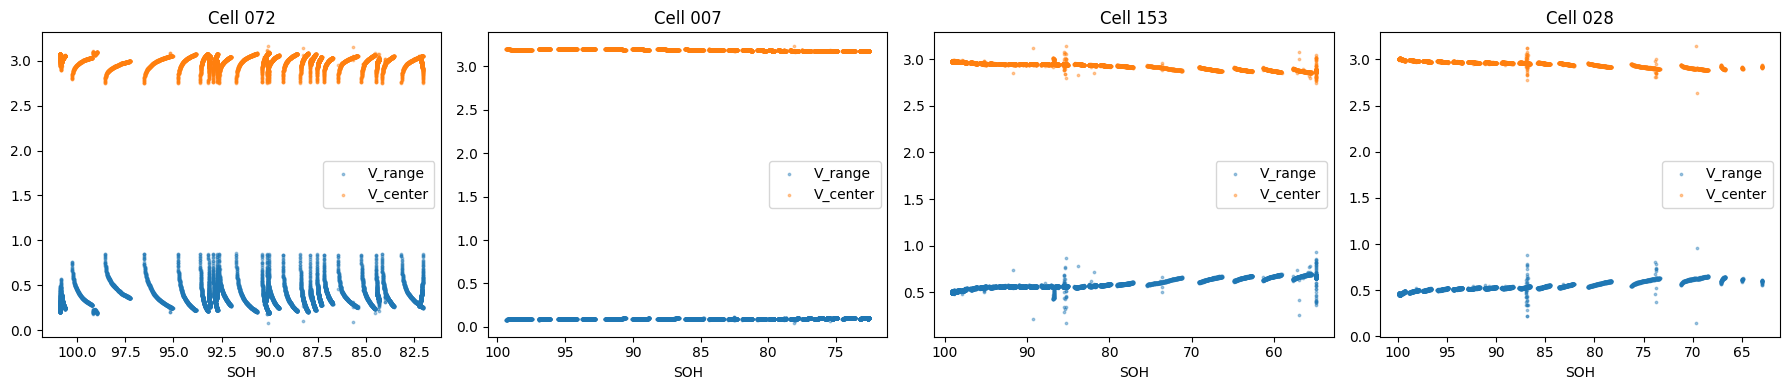

In [9]:
import s3fs, re, pyarrow.parquet as pq, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from s3_credentials import S3_ACCESS_KEY, S3_SECRET_KEY
OPTS={"key":S3_ACCESS_KEY,"secret":S3_SECRET_KEY,
      "client_kwargs":{"endpoint_url":"https://iseadocker.isea.rwth-aachen.de:9000","region_name":"us-east-1"},
      "config_kwargs":{"s3":{"addressing_style":"path"},"signature_version":"s3v4"}}
fs=s3fs.S3FileSystem(**OPTS)
RAWBASE="projects/j8005-metabatt/Metabatt/A123"
CAP="projects/j8005-metabatt/Metabatt/A123/40_capacity_monitore"
def TS(s): return pd.to_datetime(s,format='ISO8601')

def check_vrange_vs_soh(BID):
    cap=pd.read_csv(f"s3://{CAP}/METABatt_A123_APR18650M1B_{BID}_capacity.csv",storage_options=OPTS)
    I_thresh=3*cap.dropna(subset=['Capacity_py'])['Capacity_py'].min()*0.8
    soh=cap.dropna(subset=['SOH']).copy(); soh['t']=TS(soh['CAP_start_time'])
    soh=soh.sort_values('t'); soh_t=soh['t'].values.astype('datetime64[s]').astype(float); soh_v=soh['SOH'].values
    BASE=f"{RAWBASE}/METABatt_A123_APR18650M1B_{BID}"
    aging=sorted([f for f in fs.ls(BASE) if 'Aging' in f and 'Cyc' in f],
                 key=lambda f: re.search(r'(\d{4}-\d{2}-\d{2})',f.split('/')[-1]).group(1))
    recs=[]
    for f in aging:
        with fs.open(f) as fh:
            d=pq.ParquetFile(fh).read(columns=['Zeit','Spannung','Strom','Prozedur']).to_pandas()
        d=d[d['Prozedur'].str.contains('Aging_APR_Cyc')].reset_index(drop=True)
        if len(d)==0: continue
        d['Zeit']=TS(d['Zeit'])
        is_dch=(d['Strom'].values<-I_thresh); diff=np.diff(is_dch.astype(int))
        st=np.where(diff==1)[0]+1; en=np.where(diff==-1)[0]+1
        if is_dch[0]: st=np.r_[0,st]
        if is_dch[-1]: en=np.r_[en,len(d)]
        for s,e in zip(st,en):
            if e-s<10: continue
            seg=d.iloc[s:e]; V=seg['Spannung'].values
            # 用5/95分位避免极值噪声
            vlo,vhi=np.percentile(V,5),np.percentile(V,95)
            tsec=np.float64(seg['Zeit'].iloc[0].value)//10**9
            recs.append({'SOH':np.interp(tsec,soh_t,soh_v),
                         'V_range':vhi-vlo,'V_center':(vhi+vlo)/2,'V_hi':vhi,'V_lo':vlo})
    r=pd.DataFrame(recs)
    # 相关性
    print(f"{BID}: V_range vs SOH 相关性={r['V_range'].corr(r['SOH']):.3f}, "
          f"V_center vs SOH={r['V_center'].corr(r['SOH']):.3f}")
    return r

fig,axes=plt.subplots(1,4,figsize=(18,4))
for ax,bid in zip(axes,['072','007','153','028']):
    r=check_vrange_vs_soh(bid)
    ax.scatter(r['SOH'],r['V_range'],s=3,alpha=0.4,label='V_range')
    ax.scatter(r['SOH'],r['V_center'],s=3,alpha=0.4,label='V_center')
    ax.set_xlabel('SOH'); ax.set_title(f'Cell {bid}'); ax.legend(); ax.invert_xaxis()
plt.tight_layout(); plt.savefig('vrange_check.png',dpi=120); plt.show()